In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent / "src"))
import numpy as np
import matplotlib.pyplot as plt
import config, data

COLOR_POS, COLOR_NEG, COLOR_FLIP = "#C44E52", "#4C72B0", "#111111"
SEED0 = config.seeds(config.N_REPS)[0]
print("global seed:", config.SEED, "| first child seed:", SEED0)

global seed: 20252026 | first child seed: 1700560607


In [4]:
tr, te = data.make_synthetic_split("moons", SEED0, eta=0.10)
print(f"train {tr.X.shape}  test {te.X.shape}")
print(f"positive fraction (clean): train {np.mean(tr.y_clean == 1):.3f}  test {np.mean(te.y_clean == 1):.3f}")
print(f"empirical flip rate: train {tr.flipped.mean():.4f}  test {te.flipped.mean():.4f}  (target 0.10)")

train (2000, 2)  test (10000, 2)
positive fraction (clean): train 0.492  test 0.509
empirical flip rate: train 0.0990  test 0.1005  (target 0.10)


In [5]:
for sigma in (0.05, 0.10):
    _, r0 = data.bayes_risk_moons(sigma)
    print(f"sigma = {sigma:.2f}  ->  r0 = {r0 * 100:.4f}%")


for eta in config.ETAS:
    risk, r0 = data.bayes_risk_moons(config.MOONS["sigma"], eta=eta)
    print(f"eta = {eta:.2f}  ->  Bayes risk = {risk * 100:.3f}%")

sigma = 0.05  ->  r0 = 0.0000%
sigma = 0.10  ->  r0 = 0.0624%
eta = 0.00  ->  Bayes risk = 0.000%
eta = 0.05  ->  Bayes risk = 5.000%
eta = 0.10  ->  Bayes risk = 10.000%
eta = 0.20  ->  Bayes risk = 20.000%


In [6]:
dg_tr, dg_te = data.make_synthetic_split("diagonal", SEED0)
proj = np.abs(dg_tr.X @ data.W_DIAG)
gamma = config.DIAGONAL["gamma"]
a = gamma * np.sqrt(2.0)

rng = np.random.default_rng(0)
raw = rng.uniform(-1.0, 1.0, size=(200_000, 2))
print(f"min |w.x| = {proj.min():.4f}   (gamma = {gamma})")
print(f"rejected fraction: empirical {np.mean(np.abs(raw @ data.W_DIAG) < gamma):.4f}"
      f"   predicted {a - a**2 / 4:.4f}")
print(f"positive fraction: {np.mean(dg_tr.y == 1):.3f}")

min |w.x| = 0.1201   (gamma = 0.12)
rejected fraction: empirical 0.1632   predicted 0.1625
positive fraction: 0.511


In [7]:
for name, (a_, b_) in {"moons": (tr, te), "diagonal": (dg_tr, dg_te)}.items():
    shared = set(map(tuple, a_.X.round(9))) & set(map(tuple, b_.X.round(9)))
    print(f"{name:9s} shared rows between train and test: {len(shared)}")

moons     shared rows between train and test: 0
diagonal  shared rows between train and test: 0


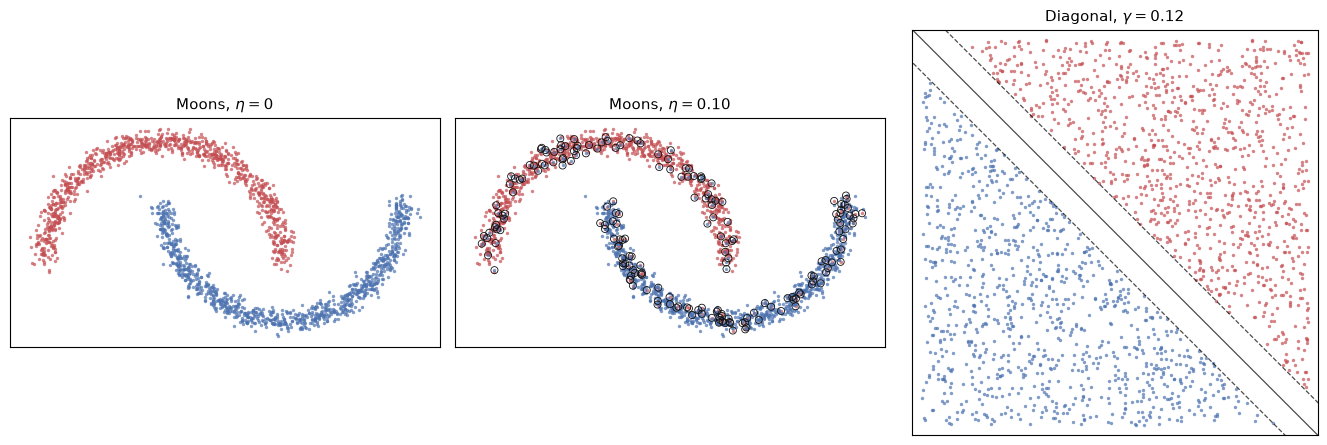

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))

clean, _ = data.make_synthetic_split("moons", SEED0, eta=0.0)
panels = [
    (clean, "Moons, $\\eta = 0$", None),
    (tr, "Moons, $\\eta = 0.10$", "flipped"),
    (dg_tr, f"Diagonal, $\\gamma = {gamma}$", "margin"),
]

for ax, (ds, title, extra) in zip(axes, panels):
    for lab, col in ((1, COLOR_POS), (-1, COLOR_NEG)):
        m = ds.y == lab
        ax.scatter(ds.X[m, 0], ds.X[m, 1], s=6, c=col, alpha=.7, lw=0)
    if extra == "flipped":
        ax.scatter(ds.X[ds.flipped, 0], ds.X[ds.flipped, 1], s=26,
                   facecolors="none", edgecolors=COLOR_FLIP, lw=.6)
    if extra == "margin":
        t = np.linspace(-1.6, 1.6, 2)
        n_ = np.array([-data.W_DIAG[1], data.W_DIAG[0]])
        for off, style in ((-gamma, "--"), (0.0, "-"), (gamma, "--")):
            P = off * data.W_DIAG + np.outer(t, n_)
            ax.plot(P[:, 0], P[:, 1], style, c="k", lw=.9, alpha=.7)
        ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
    ax.set_title(title, fontsize=11)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])

fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "synthetic_datasets.pdf", bbox_inches="tight")
plt.show()

In [10]:
sb = data.load_spambase()
print(f"shape {sb.X.shape}   positive fraction {np.mean(sb.y == 1):.4f}")
print(f"majority-class error rate: {min(np.mean(sb.y == 1), np.mean(sb.y == -1)):.4f}")
print(f"NaNs: {np.isnan(sb.X).sum()}")

n_uniq = np.array([len(np.unique(col)) for col in sb.X.T])
zero_frac = np.mean(sb.X == 0.0, axis=0)
print(f"\ndistinct values per feature: min {n_uniq.min()}, median {int(np.median(n_uniq))}, max {n_uniq.max()}")
print(f"candidate thresholds: {n_uniq.sum() - len(n_uniq)} distinct vs "
      f"{sb.X.shape[0] * sb.X.shape[1]} naive")
print(f"features with >50% zeros: {(zero_frac > .5).sum()} / {sb.d}")

shape (4601, 57)   positive fraction 0.3940
majority-class error rate: 0.3940
NaNs: 0

distinct values per feature: min 38, median 177, max 2161
candidate thresholds: 15037 distinct vs 262257 naive
features with >50% zeros: 50 / 57


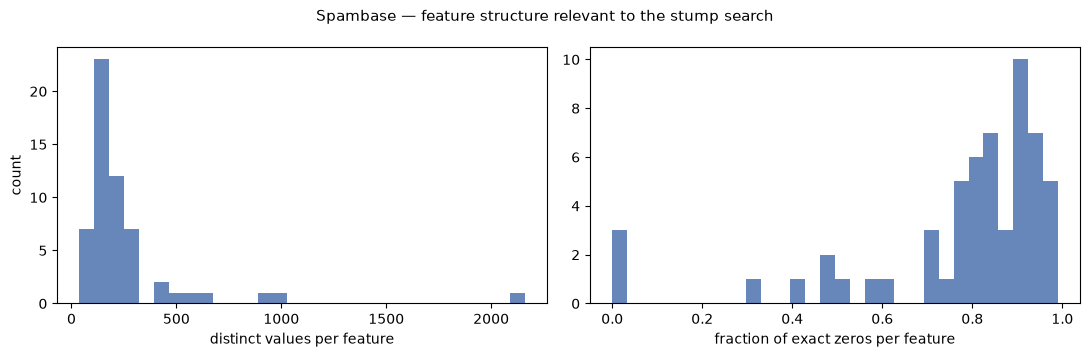

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(n_uniq, bins=30, color=COLOR_NEG, alpha=.85)
axes[0].set_xlabel("distinct values per feature"); axes[0].set_ylabel("count")
axes[1].hist(zero_frac, bins=30, color=COLOR_NEG, alpha=.85)
axes[1].set_xlabel("fraction of exact zeros per feature")
fig.suptitle("Spambase — feature structure relevant to the stump search", fontsize=11)
fig.tight_layout()
plt.show()